# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1888s 11us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

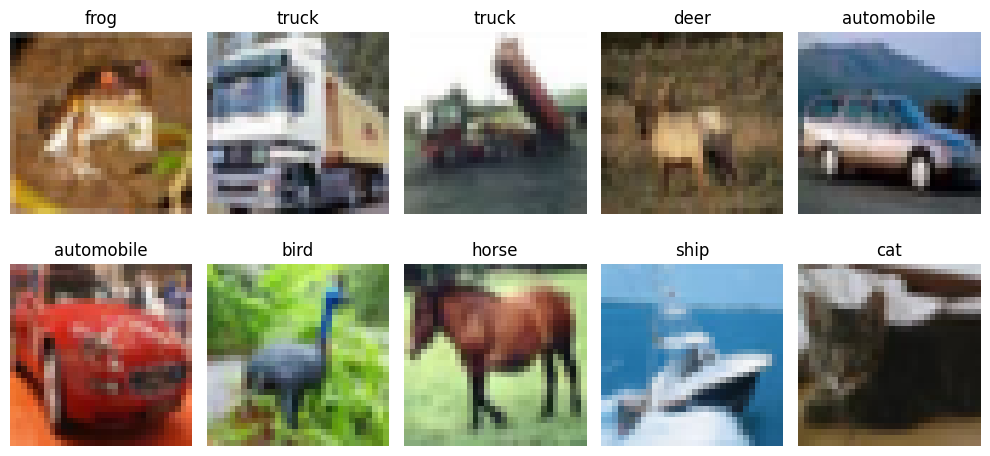

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.2693 - loss: 1.9974 - val_accuracy: 0.3296 - val_loss: 1.8502
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3117 - loss: 1.8749 - val_accuracy: 0.3526 - val_loss: 1.8144
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3290 - loss: 1.8274 - val_accuracy: 0.3626 - val_loss: 1.7745
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3398 - loss: 1.8074 - val_accuracy: 0.3758 - val_loss: 1.7529
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3568 - loss: 1.7707 - val_accuracy: 0.3818 - val_loss: 1.7194
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3614 - loss: 1.7535 - val_accuracy: 0.3904 - val_loss: 1.7060
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3656 - loss: 1.7358 - val_accuracy: 0.3906 - val_loss: 1.7058
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3703 - loss: 1.7257 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4263 - loss: 1.6390
ANN Test Accuracy: 0.4262999892234802


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 69ms/step - accuracy: 0.4707 - loss: 1.4831 - val_accuracy: 0.5690 - val_loss: 1.2209
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.6096 - loss: 1.1231 - val_accuracy: 0.5980 - val_loss: 1.1832
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.6708 - loss: 0.9463 - val_accuracy: 0.6496 - val_loss: 1.0011
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.7105 - loss: 0.8274 - val_accuracy: 0.6604 - val_loss: 0.9655
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.7454 - loss: 0.7296 - val_accuracy: 0.6688 - val_loss: 0.9850
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.7696 - loss: 0.6554 - val_accuracy: 0.6622 - val_loss: 1.0238
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.7948 - loss: 0.5796 - val_accuracy: 0.7022 - val_loss: 0.9297
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.8156 - loss: 0.5229 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7221 - loss: 0.9106
CNN Test Accuracy: 0.722100019454956


## 📈 Compare Learning Curves

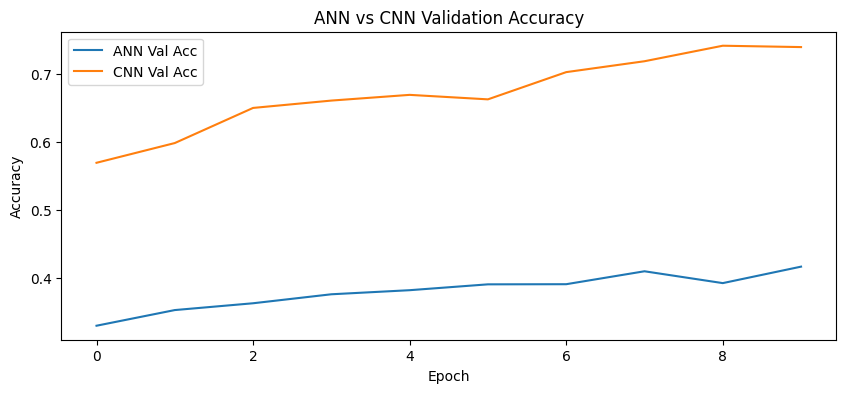

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping prevents unnecessary training once validation performance stops improving.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 81ms/step - accuracy: 0.4035 - loss: 1.6587 - val_accuracy: 0.5220 - val_loss: 1.3500
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 77ms/step - accuracy: 0.5078 - loss: 1.3894 - val_accuracy: 0.5626 - val_loss: 1.2479
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 77ms/step - accuracy: 0.5546 - loss: 1.2730 - val_accuracy: 0.5742 - val_loss: 1.2166
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.5867 - loss: 1.1911 - val_accuracy: 0.6066 - val_loss: 1.1777
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6071 - loss: 1.1345 - val_accuracy: 0.6104 - val_loss: 1.1537
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6244 - loss: 1.0882 - val_accuracy: 0.6490 - val_loss: 1.0149
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.6376 - loss: 1.0409 - val_accuracy: 0.6516 - val_loss: 1.0179
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 81ms/step - accuracy: 0.6504 - loss: 1.0096 - 

# 📊 Final Comparison Table

In [11]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm, y_test, verbose=0
)

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN (BatchNorm + Dropout)", "CNN + Data Augmentation"],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})

comparison["Test Accuracy (%)"] = comparison["Test Accuracy"] * 100
comparison = comparison.drop(columns=["Test Accuracy"])

comparison

,Model,Test Loss,Test Accuracy (%)
0,ANN,1.639008,42.629999
1,CNN (BatchNorm + Dropout),0.910612,72.210002
2,CNN + Data Augmentation,0.901840,68.540001


# 🔍 Detailed Performance Analysis

The assignment asks us to analyze performance across both **architectures** and **training strategies**.

We compare:

- **ANN:** flattened images + dense layers + dropout
- **CNN:** convolution + pooling + batch normalization + dropout
- **CNN + Data Augmentation:** CNN with image transformations and early stopping

The main questions are:
1. Does CNN outperform ANN?
2. Does data augmentation improve generalization?
3. What happens to training and validation accuracy?
4. Which model gives the best test performance?

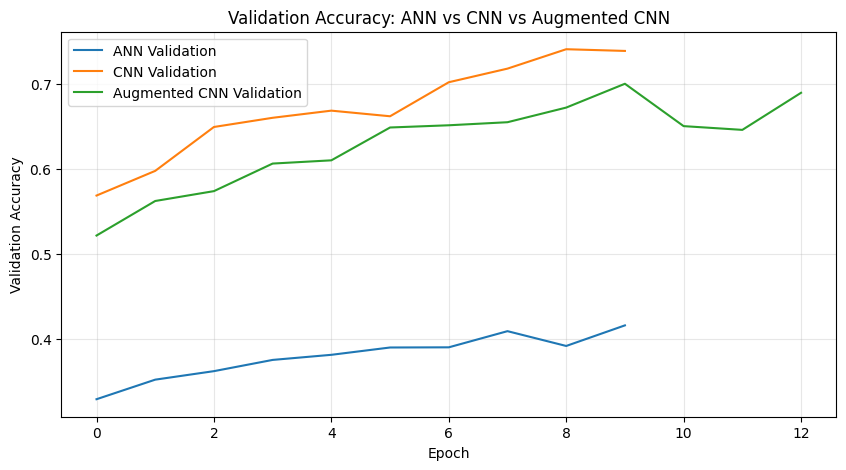

In [12]:
# Plot training and validation accuracy for all three experiments

plt.figure(figsize=(10, 5))

plt.plot(ann_history.history["val_accuracy"], label="ANN Validation")
plt.plot(cnn_history.history["val_accuracy"], label="CNN Validation")
plt.plot(aug_history.history["val_accuracy"], label="Augmented CNN Validation")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: ANN vs CNN vs Augmented CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

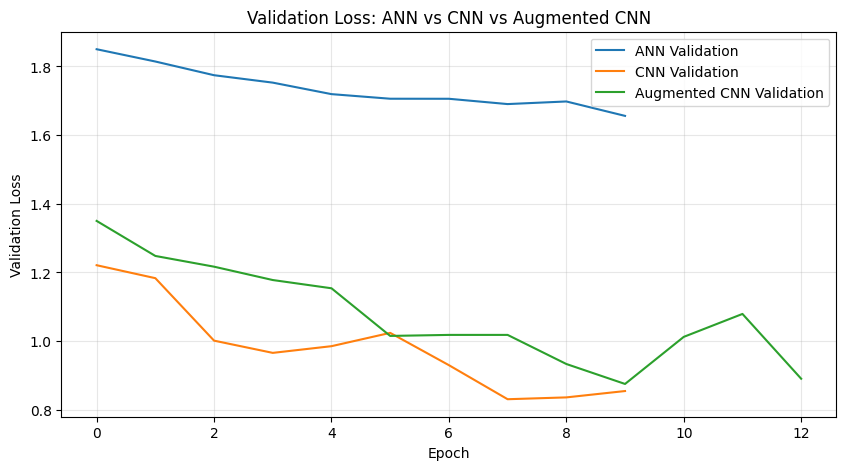

In [13]:
# Plot validation loss for all three experiments

plt.figure(figsize=(10, 5))

plt.plot(ann_history.history["val_loss"], label="ANN Validation")
plt.plot(cnn_history.history["val_loss"], label="CNN Validation")
plt.plot(aug_history.history["val_loss"], label="Augmented CNN Validation")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: ANN vs CNN vs Augmented CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 🧩 Confusion Matrix

A confusion matrix helps us identify which CIFAR-10 classes the best model classifies correctly and which classes it confuses with one another.

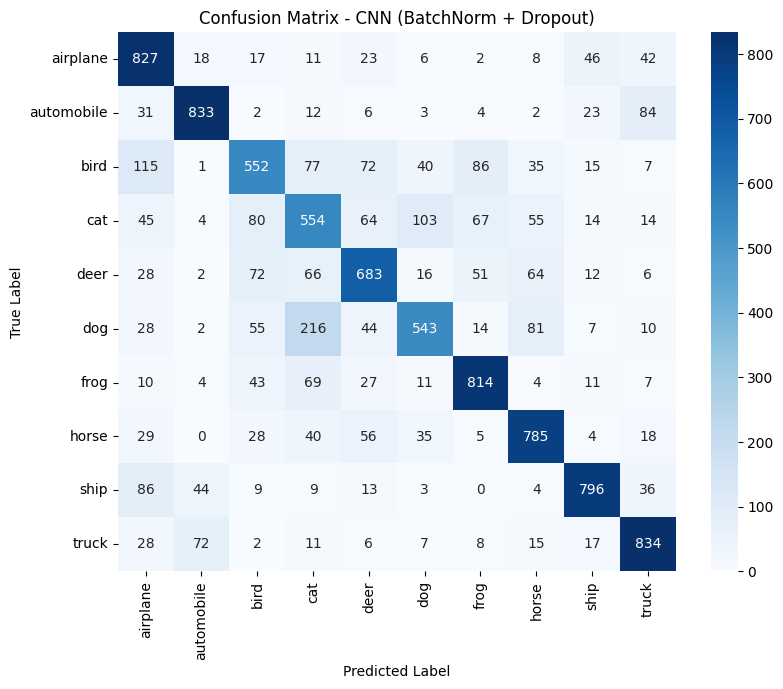

Classification Report - CNN (BatchNorm + Dropout)

              precision    recall  f1-score   support

    airplane       0.67      0.83      0.74      1000
  automobile       0.85      0.83      0.84      1000
        bird       0.64      0.55      0.59      1000
         cat       0.52      0.55      0.54      1000
        deer       0.69      0.68      0.69      1000
         dog       0.71      0.54      0.61      1000
        frog       0.77      0.81      0.79      1000
       horse       0.75      0.79      0.76      1000
        ship       0.84      0.80      0.82      1000
       truck       0.79      0.83      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Match the model names exactly with the comparison table
models_to_compare = {
    "ANN": (ann_model, x_test_flat),
    "CNN (BatchNorm + Dropout)": (cnn_model, x_test_norm),
    "CNN + Data Augmentation": (aug_cnn_model, x_test_norm)
}

# Find the best-performing model
best_name = comparison.loc[
    comparison["Test Accuracy (%)"].idxmax(), "Model"
]

best_model, best_x = models_to_compare[best_name]

# Generate predictions
pred_probs = best_model.predict(best_x, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
y_true = y_test.ravel()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

# Classification report
print(f"Classification Report - {best_name}\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# 🧠 Interpretation and Conclusion

### Architecture comparison

The **ANN** receives each image as a 3,072-element vector. Flattening removes the original 2D spatial arrangement of pixels, so the ANN does not explicitly learn local patterns such as edges, textures, and shapes.

The **CNN** keeps the 32×32 spatial structure and learns local features through convolution filters. Pooling reduces the spatial dimensions while retaining important information. Therefore, CNN is better suited to image classification.

### Training-strategy comparison

The CNN uses **Batch Normalization** and **Dropout**, which help stabilize training and reduce overfitting. The augmented CNN additionally applies random flips, rotations, and zooms during training, giving the model more varied examples and improving its ability to generalize.

**EarlyStopping** monitors validation loss and restores the best-performing weights, reducing unnecessary training once validation performance stops improving.

### Final conclusion

After running the notebook, use the final comparison table to report the exact test accuracies obtained on your Colab runtime. The expected qualitative result is:

- ANN performs worst because it ignores image spatial structure.
- CNN performs substantially better because it learns spatial features.
- CNN with data augmentation can improve generalization and may achieve the best test accuracy, although the exact improvement depends on training randomness and hardware.

This completes the required comparison of **ANN vs CNN** and the effect of **training strategies such as dropout, batch normalization, data augmentation, and early stopping**.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion

- **ANN works for CIFAR-10**, but flattening the image removes spatial information.
- **CNN performs better** because convolution layers learn spatial and hierarchical visual features.
- **Batch Normalization and Dropout** improve the CNN training process and help control overfitting.
- **Data Augmentation** exposes the model to transformed training examples and can improve generalization.
- **EarlyStopping** prevents unnecessary training after validation performance stops improving.

The final comparison table and confusion matrix provide quantitative and class-level evidence for these conclusions.